# System Design & Interview Mastery — Scalable Capital Robo-Advisor
### How to whiteboard, how to think, and how to ace every question they will ask

---

**What this notebook covers:**

1. The mental model every interviewer wants to see — how to structure any system design answer
2. Full robo-advisor architecture — every component explained with trade-offs
3. The rebalancing pipeline deep-dive — the core technical system at Scalable
4. Serverless burst compute — SQS, Lambda, and how to handle 300K clients in minutes
5. Data models — portfolio state, tax lots, orders, audit logs
6. Database design — why PostgreSQL, how to handle concurrency, idempotency
7. How to whiteboard system architecture — the exact framework to use on a whiteboard
8. Every interview question they will ask — with model answers
9. Behavioural and motivation questions — Scalable-specific prep
10. Code exercises you must be able to write cold

**Run this notebook in order. Every cell is executable — code cells produce real outputs you can study.**

```
pip install numpy scipy matplotlib cvxpy networkx
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f8',
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'font.size': 11, 'axes.titlesize': 13,
})

PURPLE = '#534AB7'; TEAL = '#1D9E75'; AMBER = '#EF9F27'
CORAL  = '#D85A30'; BLUE = '#185FA5'; GREEN = '#3B6D11'
RED    = '#A32D2D'; GRAY = '#888780'; PINK = '#D4537E'
LIGHT  = '#f0f0f8'

print('Imports OK.')

Imports OK.


---
## Part 1 — The Mental Model Every Interviewer Wants to See

Before answering any system design question, you must demonstrate **structured thinking**. Interviewers at Scalable Capital are engineers who build real systems — they will see through vague hand-waving immediately.

### The five-layer answer framework

Every system design answer must hit all five layers. Rushing to implementation details (Layer 4) without first establishing scope (Layer 1) is the most common failure mode.

| Layer | What you do | Time on whiteboard |
|---|---|---|
| 1. Clarify requirements | Ask the right questions, establish scale | 2–3 min |
| 2. Define data flows | Boxes and arrows, no implementation | 3–5 min |
| 3. Identify the hot path | What must be fast? What can be async? | 2–3 min |
| 4. Pick components and trade-offs | SQS vs Kafka, Lambda vs ECS, etc | 5–8 min |
| 5. Address failure modes | What breaks? How do you detect and recover? | 3–5 min |

### The questions you must ask first (Layer 1)
- **Scale:** How many clients? How many trades per day?
- **Latency:** Is this real-time or near-real-time? EOD batch?
- **Consistency:** What happens if two workers process the same client?
- **Failure tolerance:** Can we lose a rebalancing event? Or is it mandatory?
- **Regulatory constraints:** Do all actions need an audit trail?

For Scalable Capital specifically, the answers are:
- Scale: ~300K+ clients, potentially millions of trades per day
- Latency: client deposits must trigger rebalancing within seconds; EOD batch can take minutes
- Consistency: absolutely cannot double-trade a client; idempotency is mandatory
- Failure: every rebalancing event must eventually complete; the system must be durable
- Regulatory: full audit trail required for MiFID II compliance

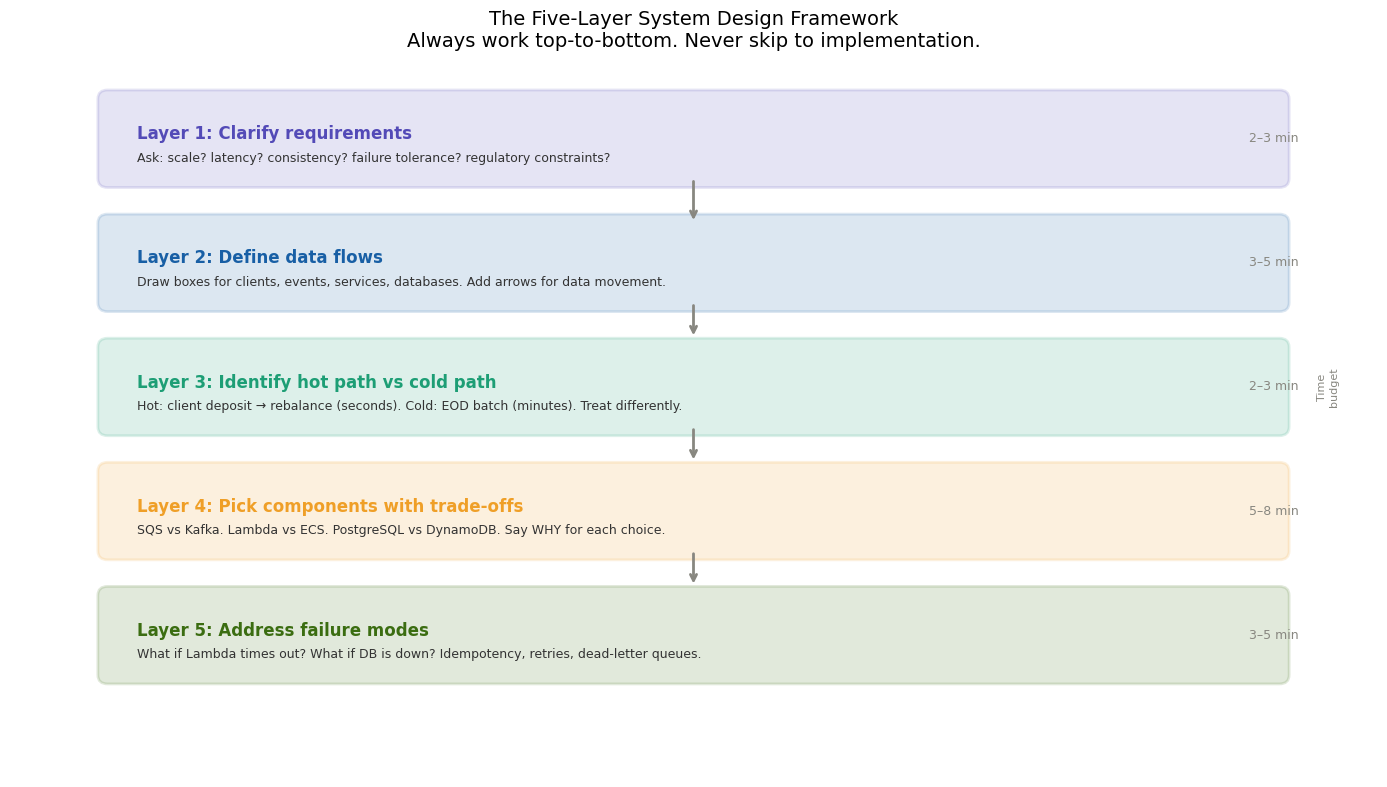

Framework reminder:
  DO: Start with requirements. Draw data flows before naming technologies.
  DO: State every trade-off explicitly: "I choose X over Y because Z."
  DO: Address failure modes unprompted — it shows production experience.
  DON'T: Jump to "we should use Kafka" without establishing why streaming is needed.
  DON'T: Leave constraints unstated — always say "assuming X, I would..."


In [2]:
# ── Visualise the five-layer framework as a decision flowchart ───────────────
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14); ax.set_ylim(0, 8)
ax.axis('off')

layers = [
    (1, 7.2, PURPLE, 'Layer 1: Clarify requirements',
     'Ask: scale? latency? consistency? failure tolerance? regulatory constraints?'),
    (1, 5.8, BLUE,   'Layer 2: Define data flows',
     'Draw boxes for clients, events, services, databases. Add arrows for data movement.'),
    (1, 4.4, TEAL,   'Layer 3: Identify hot path vs cold path',
     'Hot: client deposit → rebalance (seconds). Cold: EOD batch (minutes). Treat differently.'),
    (1, 3.0, AMBER,  'Layer 4: Pick components with trade-offs',
     'SQS vs Kafka. Lambda vs ECS. PostgreSQL vs DynamoDB. Say WHY for each choice.'),
    (1, 1.6, GREEN,  'Layer 5: Address failure modes',
     'What if Lambda times out? What if DB is down? Idempotency, retries, dead-letter queues.'),
]

for x, y, col, title, desc in layers:
    fancy = FancyBboxPatch((x, y-0.45), 12, 0.9, boxstyle='round,pad=0.1',
                            facecolor=col, alpha=0.15, edgecolor=col, linewidth=2)
    ax.add_patch(fancy)
    ax.text(x+0.3, y+0.05, title, fontsize=12, fontweight='bold', color=col, va='center')
    ax.text(x+0.3, y-0.22, desc,  fontsize=9,  color='#333333',   va='center')

# Arrows between layers
for y_from, y_to in [(6.75, 6.25), (5.35, 4.95), (3.95, 3.55), (2.55, 2.15)]:
    ax.annotate('', xy=(7, y_to), xytext=(7, y_from),
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=2))

# Time budget annotation
ax.text(13.2, 7.2, '2–3 min', fontsize=9, color=GRAY, va='center', ha='right')
ax.text(13.2, 5.8, '3–5 min', fontsize=9, color=GRAY, va='center', ha='right')
ax.text(13.2, 4.4, '2–3 min', fontsize=9, color=GRAY, va='center', ha='right')
ax.text(13.2, 3.0, '5–8 min', fontsize=9, color=GRAY, va='center', ha='right')
ax.text(13.2, 1.6, '3–5 min', fontsize=9, color=GRAY, va='center', ha='right')
ax.text(13.5, 4.4, 'Time\nbudget', fontsize=8, color=GRAY, va='center', ha='center', rotation=90)

ax.set_title('The Five-Layer System Design Framework\n'
             'Always work top-to-bottom. Never skip to implementation.', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print('Framework reminder:')
print('  DO: Start with requirements. Draw data flows before naming technologies.')
print('  DO: State every trade-off explicitly: "I choose X over Y because Z."')
print('  DO: Address failure modes unprompted — it shows production experience.')
print('  DON\'T: Jump to "we should use Kafka" without establishing why streaming is needed.')
print('  DON\'T: Leave constraints unstated — always say "assuming X, I would..."')

---
## Part 2 — Full Robo-Advisor Architecture

This is the complete system you are being asked to build and maintain at Scalable Capital. Every box and arrow here corresponds to real engineering decisions you must be able to justify.

### The three planes of the system

**Control plane (slow, configuration):** Investment strategy, risk model parameters, ETF universe, target portfolio weights by risk level. Changes infrequently. Managed by quants. Stored in a versioned database.

**Data plane (medium, daily):** Market prices, covariance matrix estimates, Vorabpauschale calculations, corporate actions. Updated daily. Consumed by the compute plane.

**Compute plane (fast, per-client):** Individual portfolio rebalancing, trade generation, order routing. Must be parallelisable, idempotent, and observable.

### Key design decision: why event-driven?
A polling architecture ("check every client every 5 minutes") doesn't scale. With 300K clients, 5-minute polling means checking 1,000 clients/second continuously — expensive and wasteful when 95%+ have no pending action. An **event-driven** architecture means work only happens when something changes: a client makes a deposit, market prices drift past a threshold, or the EOD batch fires. This is exactly how Scalable's system works.

In [ ]:
# ── Draw the full robo-advisor architecture diagram ─────────────────────────
fig, ax = plt.subplots(figsize=(16, 11))
ax.set_xlim(0, 16); ax.set_ylim(0, 11)
ax.axis('off')
ax.set_facecolor('white')

def draw_box(ax, x, y, w, h, label, sublabel, color, alpha=0.18):
    box = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.12',
                          facecolor=color, alpha=alpha, edgecolor=color, linewidth=1.8)
    ax.add_patch(box)
    ax.text(x+w/2, y+h*0.62, label,    fontsize=9,  fontweight='bold', color=color,
            ha='center', va='center')
    ax.text(x+w/2, y+h*0.28, sublabel, fontsize=7.5, color='#444444',
            ha='center', va='center')

def arrow(ax, x1, y1, x2, y2, col=GRAY, label='', lw=1.5):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=col, lw=lw))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.05, my+0.07, label, fontsize=7, color=col)

# ── CLIENT LAYER ─────────────────────────────────────────────────────────────
draw_box(ax, 0.3, 9.5, 3.2, 1.1, 'Client layer',
         'Web/mobile: deposits,\nwithdrawals, risk changes', PURPLE)

# ── API GATEWAY ──────────────────────────────────────────────────────────────
draw_box(ax, 4.2, 9.5, 3.2, 1.1, 'API Gateway / Load Balancer',
         'Auth (JWT), rate limiting,\nrequest routing', BLUE)

# ── EVENT BUS ────────────────────────────────────────────────────────────────
draw_box(ax, 8.2, 9.5, 3.4, 1.1, 'Event Bus (SQS + SNS)',
         'ClientEvent queue, DLQ,\nfanout to consumers', TEAL)

# ── DRIFT MONITOR ────────────────────────────────────────────────────────────
draw_box(ax, 12.2, 9.5, 3.5, 1.1, 'Drift Monitor (Lambda)',
         'EOD: check all portfolios,\nenqueue if |w-w*|>eps', AMBER)

arrow(ax, 3.5, 10.05, 4.2, 10.05, PURPLE)   # client -> gateway
arrow(ax, 7.4, 10.05, 8.2, 10.05, BLUE)     # gateway -> event bus
arrow(ax, 12.2, 10.05, 11.6, 10.05, AMBER)  # drift monitor -> event bus

# ── SHARED DATA SERVICES ─────────────────────────────────────────────────────
draw_box(ax, 0.3, 7.5, 2.2, 1.3, 'Market Data\nService',
         'ETF prices, NAV,\nspread estimates', CORAL)
draw_box(ax, 2.8, 7.5, 2.4, 1.3, 'Risk Model\nService',
         'Covariance matrix Σ,\nLedoit-Wolf, factors', CORAL)
draw_box(ax, 5.5, 7.5, 2.4, 1.3, 'Strategy\nService',
         'Target weights w* per\nrisk level, BL params', CORAL)
draw_box(ax, 8.2, 7.5, 2.4, 1.3, 'Tax Service',
         'Lot data, Vorabpausch.,\ncountry tax rules', CORAL)
draw_box(ax, 10.9, 7.5, 2.4, 1.3, 'Portfolio\nDB (RDS)',
         'Holdings, lots, orders,\nPortfolioState table', GREEN)
draw_box(ax, 13.6, 7.5, 2.1, 1.3, 'S3 Audit\nStore',
         'Immutable audit log,\nMiFID II compliance', TEAL)

# ── LAMBDA WORKER POOL ───────────────────────────────────────────────────────
draw_box(ax, 3.0, 5.2, 9.8, 1.8, 'Lambda Worker Pool  (1,000+ concurrent)',
         'Per-client job: (1) fetch holdings + prices + Σ  →  (2) run cvxpy optimizer  →'
         '  (3) generate trade list  →  (4) write trades atomically to DB',
         PURPLE, alpha=0.12)

# Internal worker sub-boxes
for xi, lbl, sl, col in [
    (3.3, 'Enrich', 'Load client state', BLUE),
    (5.8, 'Optimize', 'cvxpy QP solve', PURPLE),
    (8.3, 'Tax-adjust', 'Lot select + TLH', AMBER),
    (10.8, 'Write', 'Atomic DB write', GREEN),
]:
    draw_box(ax, xi, 5.45, 2.2, 1.25, lbl, sl, col, alpha=0.25)
    if xi < 10.8:
        arrow(ax, xi+2.2, 6.07, xi+2.5, 6.07, col, lw=1.2)

# ── ORDER AGGREGATION ────────────────────────────────────────────────────────
draw_box(ax, 3.0, 3.4, 5.0, 1.5, 'Order Aggregation & Netting',
         'Sum client buys/sells per ETF.\nInternal cross: match A\'s sell vs B\'s buy.\n'
         'Net residual goes to exchange.', TEAL)
draw_box(ax, 9.2, 3.4, 4.5, 1.5, 'Execution Layer (EIX/OTC)',
         'Route net orders to European\nInvestor Exchange or OTC.\n'
         'Fill confirmations → update lots.', CORAL)

# ── INFRA ────────────────────────────────────────────────────────────────────
draw_box(ax, 0.3, 1.3, 5.0, 1.5, 'Infrastructure (Terraform IaC)',
         'AWS: VPC, Lambda, RDS PostgreSQL,\n'
         'SQS, S3, CloudWatch, IAM roles.\n'
         'All defined in .tf files — no manual console.', GRAY)
draw_box(ax, 6.0, 1.3, 5.0, 1.5, 'CI/CD Pipeline (GitHub Actions)',
         'PR → pytest suite (unit + integration)\n'
         '→ Docker build → ECR push → Terraform apply\n'
         '→ canary deploy → full rollout.', GRAY)
draw_box(ax, 11.3, 1.3, 4.4, 1.5, 'Observability',
         'CloudWatch metrics: solve_time_ms,\n'
         'drift_magnitude, trades_per_second.\n'
         'PagerDuty alerts on solver_error > 0.', GRAY)

# Connecting arrows
arrow(ax, 9.9, 9.5,  9.9, 7.1,  TEAL,  'enqueue\nclient jobs', lw=1.5)
arrow(ax, 1.4, 7.5,  1.4, 7.0,  CORAL)
arrow(ax, 4.0, 7.5,  4.0, 7.0,  CORAL)
arrow(ax, 6.7, 7.5,  6.7, 7.0,  CORAL)
arrow(ax, 9.4, 7.5,  9.4, 7.0,  CORAL)

ax.annotate('', xy=(5.5, 6.95), xytext=(5.5, 7.5),
            arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.5))
ax.text(5.2, 7.2, 'shared\ndata', fontsize=7, color=CORAL)

arrow(ax, 8.0, 5.9, 8.2, 5.9, PURPLE, lw=1)
arrow(ax, 11.2, 5.9, 11.7, 5.9, PURPLE, lw=1)

arrow(ax, 7.9, 5.2, 5.5, 4.9, PURPLE, lw=1.5)
arrow(ax, 11.5, 4.9, 9.2, 4.7, TEAL, lw=1.5)

ax.set_title('Scalable Capital Robo-Advisor: Complete System Architecture\n'
             'Event-driven | Serverless burst | Idempotent | Fully audited | IaC',
             fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print('Architecture summary:')
print('  Event sources: client actions (deposit/withdraw/risk change) + EOD drift monitor')
print('  Message bus: SQS for durability, at-least-once delivery, visibility timeout')
print('  Compute: Lambda burst (1000+ concurrent) — stateless, parallel, cheap')
print('  Storage: PostgreSQL (transactional portfolio state) + S3 (audit logs)')
print('  Netting: internal crossing before market — saves bid-ask on both sides')
print('  IaC: every resource in Terraform — reproducible, auditable, no surprises')

---
## Part 3 — The Rebalancing Pipeline: Every Step Explained

This is the **core technical process** at Scalable Capital — automated management of billions in client assets. Every step has specific engineering requirements.

### Step 1: Trigger
**What:** A message arrives in the SQS queue containing a `client_id` and `trigger_type` (`DEPOSIT`, `WITHDRAWAL`, `RISK_CHANGE`, `EOD_DRIFT`, `SECURITY_TRANSITION`).

**Why SQS?** SQS provides at-least-once delivery with a configurable visibility timeout. While a Lambda worker processes a job, the message is invisible to other workers. If the Lambda times out or crashes, the message becomes visible again and another worker picks it up. This gives you fault tolerance without complex coordination.

**Trade-off vs Kafka:** Kafka offers ordering guarantees and replay — useful if you need to replay the exact sequence of events. SQS is simpler, fully managed, and sufficient when ordering doesn't matter (parallel client processing is independent). At Scalable's scale, SQS is the right choice.

### Step 2: Enrich (fetch all data in one DB query)
The Lambda worker fetches everything needed for the optimization in a **single database round-trip**:
```sql
SELECT p.holdings, p.target_weights, p.risk_level,
       l.lot_id, l.quantity, l.cost_basis, l.acquisition_date, l.fund_type,
       pr.price, pr.bid, pr.ask, pr.daily_vol
FROM portfolios p
JOIN lots l ON l.client_id = p.client_id AND l.closed_at IS NULL
JOIN prices pr ON pr.asset_id = l.asset_id AND pr.price_date = CURRENT_DATE
WHERE p.client_id = $1
```
**Why one query?** Database round-trips in Lambda add ~1–5ms each. At 1,000 concurrent workers making 5 queries each = 5,000 concurrent connections. PostgreSQL's connection limit is ~500 (via pgBouncer pooling, up to ~2,000). One query per worker = one connection per worker = manageable.

### Step 3: Optimize (cvxpy QP)
The rebalancing optimization runs in-memory. Key requirements:
- **Idempotency:** the optimizer is a pure function — same inputs → same outputs
- **Warm-starting:** use `cp.Parameter` so the problem doesn't recompile per client
- **Timeout guard:** wrap the solve in a try/except with a 10-second timeout; fall back to proportional rebalancing

### Step 4: Tax adjustment (lot selection)
After the optimizer outputs the trade vector `Δw`, the tax module selects which lots to sell using the highest-cost-basis-first greedy algorithm. This is deterministic and fast (O(M log M) sort).

### Step 5: Write atomically
All portfolio state changes (new holdings, closed lots, trade records) must be written in a **single database transaction**. If the write fails partway, the entire transaction rolls back. The job message stays in SQS until the Lambda function returns successfully — then SQS deletes it.

### Step 6: Order aggregation
After all client optimizations complete, orders are aggregated across clients. A client-A sell and client-B buy of the same ETF net against each other — only the difference hits the market. The platform advantage of managing many clients together.

In [ ]:
# ── Rebalancing pipeline: timing, concurrency, and netting simulation ───────
np.random.seed(42)

# ── Simulate processing times for the pipeline steps ─────────────────────────
n_clients = 1000
step_times = {
    'SQS dequeue':    np.random.exponential(0.5, n_clients),
    'DB enrich':      np.random.gamma(2, 1.5, n_clients),
    'cvxpy optimize': np.random.gamma(3, 18, n_clients),
    'Tax lot select': np.random.exponential(0.8, n_clients),
    'DB write':       np.random.gamma(2, 2.0, n_clients),
}
total_times = sum(step_times.values())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Step time distributions
colors_steps = [GRAY, BLUE, PURPLE, AMBER, TEAL]
for i, (step, times) in enumerate(step_times.items()):
    if i < 5:
        ax_i = axes[i // 3][i % 3]
        ax_i.hist(times, bins=40, color=colors_steps[i], alpha=0.8, edgecolor='white')
        ax_i.axvline(np.mean(times), color=RED, lw=2, ls='--',
                     label=f'Mean: {np.mean(times):.1f} ms')
        ax_i.axvline(np.percentile(times, 95), color=CORAL, lw=1.5, ls=':',
                     label=f'P95: {np.percentile(times, 95):.1f} ms')
        ax_i.set_xlabel('Time (ms)'); ax_i.set_ylabel('Count')
        ax_i.set_title(f'Step: {step}')
        ax_i.legend(fontsize=8)

# Total time and concurrency throughput
ax_total = axes[1][2]
ax_total.hist(total_times, bins=40, color=PURPLE, alpha=0.8, edgecolor='white')
ax_total.axvline(np.mean(total_times), color=AMBER, lw=2.5, ls='--',
                 label=f'Mean total: {np.mean(total_times):.0f} ms')
ax_total.axvline(np.percentile(total_times, 99), color=RED, lw=1.5, ls=':',
                 label=f'P99: {np.percentile(total_times, 99):.0f} ms')

# Throughput annotation
for n_workers in [100, 500, 1000, 3000]:
    t_wall = np.mean(total_times) * 300_000 / n_workers / 1000
    ax_total.axvline(-1, color='white', lw=0, label=f'{n_workers} workers → {t_wall:.0f}s for 300K')
ax_total.set_xlabel('Total per-client time (ms)'); ax_total.set_ylabel('Count')
ax_total.set_title('Total pipeline time (sum of all steps)')
ax_total.legend(fontsize=7)

plt.suptitle(f'Rebalancing pipeline step timing ({n_clients} simulated clients)',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Order netting simulation ───────────────────────────────────────────────
n_clients_net = 50_000
ETF_NAMES = ['MSCI World', 'EM Equity', 'Gov Bond', 'Corp Bond', 'Gold ETF']
target_w = np.array([0.35, 0.20, 0.25, 0.10, 0.10])

# Simulate drift and trade vectors
drift_noise = np.random.normal(0, 0.04, (n_clients_net, 5))
w_clients = np.clip(target_w + drift_noise, 0, 1)
w_clients /= w_clients.sum(axis=1, keepdims=True)
port_values = np.exp(np.random.normal(np.log(50_000), 0.9, n_clients_net))

rebal_frac = 0.60
trades_w = (target_w - w_clients) * rebal_frac
trades_eur = trades_w * port_values[:, np.newaxis]

gross_buys  = np.maximum(trades_eur,  0).sum(axis=0)
gross_sells = np.maximum(-trades_eur, 0).sum(axis=0)
net_orders  = gross_buys - gross_sells
netting_pct = 1 - np.abs(net_orders).sum() / (gross_buys + gross_sells).sum()
spread_bps  = 3
cost_saved  = (gross_buys + gross_sells - np.abs(net_orders)).sum() * spread_bps / 10000

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(5); wb = 0.28
axes2[0].bar(x - wb, gross_buys/1e6,         wb, color=GREEN, label='Gross buys (€M)',   alpha=0.85)
axes2[0].bar(x,      gross_sells/1e6,         wb, color=CORAL, label='Gross sells (€M)',  alpha=0.85)
axes2[0].bar(x + wb, np.abs(net_orders)/1e6,  wb, color=BLUE,  label='Net to market (€M)', alpha=0.9)
axes2[0].set_xticks(x); axes2[0].set_xticklabels(ETF_NAMES, rotation=15, fontsize=9)
axes2[0].set_ylabel('Order size (€ millions)')
axes2[0].set_title(f'Order aggregation across {n_clients_net:,} clients\n'
                    f'{netting_pct*100:.0f}% of gross volume netted internally')
axes2[0].legend(fontsize=9)

# Netting benefit annotation
axes2[0].text(0.98, 0.97, f'Gross buys:  €{gross_buys.sum()/1e6:.0f}M\n'
              f'Gross sells: €{gross_sells.sum()/1e6:.0f}M\n'
              f'Net to mkt:  €{np.abs(net_orders).sum()/1e6:.0f}M\n'
              f'Spread saved: €{cost_saved/1e3:.0f}k\n(@ {spread_bps}bps)',
              transform=axes2[0].transAxes, ha='right', va='top', fontsize=8,
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Concurrency vs wall time
concurrencies = [10, 50, 100, 500, 1000, 2000, 3000, 5000]
mean_ms = np.mean(total_times)
wall_times = [300_000 * mean_ms / c / 1000 for c in concurrencies]
axes2[1].loglog(concurrencies, wall_times, 'o-', color=PURPLE, lw=2.5, ms=8)
axes2[1].axhline(60,  color=AMBER, lw=1.5, ls='--', label='1 minute')
axes2[1].axhline(300, color=CORAL, lw=1.5, ls='--', label='5 minutes')
axes2[1].axhline(30,  color=GREEN, lw=1.5, ls=':',  label='30 seconds')
for c, t in zip(concurrencies, wall_times):
    axes2[1].annotate(f'{t:.0f}s', (c, t), textcoords='offset points',
                      xytext=(6, 4), fontsize=8, color=PURPLE)
axes2[1].set_xlabel('Lambda concurrent workers')
axes2[1].set_ylabel('Wall time for 300K clients (seconds)')
axes2[1].set_title(f'Throughput vs concurrency\n(mean {mean_ms:.0f}ms/client)')
axes2[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Platform statistics ({n_clients_net:,} clients):')
print(f'  Mean pipeline time per client: {mean_ms:.0f} ms')
print(f'  Netting ratio: {netting_pct*100:.0f}%  ({netting_pct*100:.0f}% of gross volume stays internal)')
print(f'  Spread saved by netting: €{cost_saved:,.0f} per rebalancing cycle (@ {spread_bps}bps)')
print(f'  At 1,000 Lambda workers: {mean_ms*300000/1000/1000:.0f}s for 300K clients')

---
## Part 4 — Data Models and Database Design

Knowing the data model is as important as knowing the algorithm. In interviews, being able to sketch a schema on a whiteboard signals engineering maturity.

### Why PostgreSQL?
The job description mentions "relational databases / SQL". Scalable uses PostgreSQL because:
1. **ACID transactions** — buying and selling lots must be atomic; you cannot half-sell a lot
2. **Optimistic locking** with `SELECT FOR UPDATE` — prevents two Lambda workers from reading the same portfolio state and generating conflicting trades
3. **JSON/JSONB** — flexible schema for holdings that vary across clients
4. **Row-level security** — can enforce client data isolation at the DB layer
5. **pgBouncer connection pooling** — enables 1,000+ Lambda functions to share a manageable number of actual DB connections

### Key design patterns

**Optimistic locking for portfolio state:**
```sql
-- Read with version number
SELECT id, holdings, version FROM portfolios WHERE client_id = $1 FOR UPDATE;
-- ... compute trades ...
-- Write only if version hasn't changed (another worker didn't get here first)
UPDATE portfolios SET holdings = $new, version = version + 1
WHERE client_id = $1 AND version = $expected_version;
-- If 0 rows updated: version conflict → retry or abandon
```

**Idempotency via job IDs:**
```sql
INSERT INTO rebalancing_jobs (job_id, client_id, status, created_at)
VALUES ($job_id, $client_id, 'processing', NOW())
ON CONFLICT (job_id) DO NOTHING;
-- If 0 rows inserted: job already exists → skip processing
```

**Lot-level accounting:**
Every lot has a unique ID, a `closed_at` timestamp (NULL = still open), and an `adjusted_basis` for Vorabpauschale adjustments. When selling, you never update the lot — you set `closed_at` and create a new lot for any residual.

In [ ]:
# ── Data model: schema, query patterns, and Python dataclasses ──────────────
from dataclasses import dataclass, field
from typing import Optional, List, Dict
from datetime import date, datetime
import json

# ── Core data classes that mirror the database schema ────────────────────────

@dataclass
class TaxLot:
    """One purchase event of an asset. Immutable once created."""
    lot_id:          str
    client_id:       str
    asset_id:        str        # ISIN or internal ETF identifier
    quantity:        float      # shares held
    cost_basis:      float      # purchase price per share (€)
    adjusted_basis:  float      # basis after Vorabpauschale adjustments
    acquisition:     date
    fund_type:       str        # 'equity' | 'mixed' | 'bond' — for Teilfreistellung
    closed_at:       Optional[datetime] = None  # None = lot is open

    def unrealised_gain(self, current_price: float) -> float:
        return self.quantity * (current_price - self.adjusted_basis)

    def gain_rate(self, current_price: float) -> float:
        """Fraction of current value that is unrealised gain."""
        return max(0, (current_price - self.adjusted_basis) / current_price)

    def tax_if_sold(self, qty: float, price: float, tax_rate: float = 0.26375) -> float:
        tf = {'equity': 0.30, 'mixed': 0.15, 'bond': 0.00}.get(self.fund_type, 0.30)
        gain = max(0, (price - self.adjusted_basis) * qty)
        return gain * (1 - tf) * tax_rate


@dataclass
class Portfolio:
    """Client portfolio state — the central object in the system."""
    client_id:      str
    risk_level:     int          # 1–10
    holdings:       Dict[str, float]  # {asset_id: shares}
    target_weights: Dict[str, float]  # {asset_id: weight}
    version:        int          # optimistic lock version
    updated_at:     datetime
    lots:           List[TaxLot] = field(default_factory=list)

    def current_weights(self, prices: Dict[str, float]) -> Dict[str, float]:
        """Compute actual weight of each asset at current prices."""
        values = {a: self.holdings.get(a, 0) * p for a, p in prices.items()}
        total = sum(values.values())
        if total <= 0:
            return {a: 0.0 for a in prices}
        return {a: v / total for a, v in values.items()}

    def max_drift(self, prices: Dict[str, float]) -> float:
        """Maximum absolute drift of any asset from its target."""
        curr = self.current_weights(prices)
        return max(abs(curr.get(a, 0) - self.target_weights.get(a, 0))
                   for a in self.target_weights)

    def needs_rebalancing(self, prices: Dict[str, float],
                           abs_threshold: float = 0.05,
                           rel_threshold: float = 0.15) -> bool:
        curr = self.current_weights(prices)
        for asset, tgt in self.target_weights.items():
            actual = curr.get(asset, 0)
            if abs(actual - tgt) > abs_threshold:
                return True
            if tgt > 0 and abs(actual - tgt) / tgt > rel_threshold:
                return True
        return False


@dataclass
class TradeOrder:
    """A single trade generated by the rebalancing optimizer."""
    order_id:      str
    client_id:     str
    asset_id:      str
    direction:     str           # 'BUY' | 'SELL'
    quantity:      float
    estimated_price: float
    lots_to_sell:  List[str]     # lot IDs being sold (SELL orders only)
    tax_estimate:  float
    job_id:        str           # links back to the rebalancing job

@dataclass
class RebalancingResult:
    """Complete output of one client's rebalancing cycle."""
    client_id:     str
    job_id:        str
    trigger:       str
    orders:        List[TradeOrder]
    pre_te:        float         # tracking error before rebalancing
    post_te:       float         # tracking error after
    tx_cost_est:   float
    tax_est:       float
    solve_time_ms: float
    status:        str           # 'completed' | 'fallback' | 'no_trade'


# ── Example: build and analyse a portfolio ────────────────────────────────────
asset_ids = ['MSCI_WORLD', 'EM_EQUITY', 'GOV_BOND', 'CORP_BOND']
prices    = {'MSCI_WORLD': 130.50, 'EM_EQUITY': 48.20, 'GOV_BOND': 102.10, 'CORP_BOND': 97.80}

example_lots = [
    TaxLot('L001', 'C001', 'MSCI_WORLD', 200, 85.0,  85.0,  date(2020, 3, 15), 'equity'),
    TaxLot('L002', 'C001', 'MSCI_WORLD', 100, 110.0, 110.0, date(2022, 6,  1), 'equity'),
    TaxLot('L003', 'C001', 'EM_EQUITY',  300, 52.0,  52.0,  date(2021, 1, 20), 'equity'),
    TaxLot('L004', 'C001', 'GOV_BOND',   500, 100.0, 100.5, date(2023, 3, 10), 'bond'),
    TaxLot('L005', 'C001', 'CORP_BOND',  250, 98.5,  98.5,  date(2022,11, 5),  'mixed'),
]

holdings = {}
for lot in example_lots:
    holdings[lot.asset_id] = holdings.get(lot.asset_id, 0) + lot.quantity

portfolio = Portfolio(
    client_id='C001', risk_level=6,
    holdings=holdings,
    target_weights={'MSCI_WORLD': 0.35, 'EM_EQUITY': 0.20, 'GOV_BOND': 0.25, 'CORP_BOND': 0.20},
    version=42,
    updated_at=datetime.now(),
    lots=example_lots
)

curr_w = portfolio.current_weights(prices)
print('Portfolio state for client C001:')
print(f'  Total value: €{sum(portfolio.holdings.get(a,0)*p for a,p in prices.items()):,.2f}')
print(f'  Needs rebalancing: {portfolio.needs_rebalancing(prices)}')
print(f'  Max drift: {portfolio.max_drift(prices)*100:.2f}%')
print()
print(f'  {"Asset":15s} {"Holdings":>10} {"Price":>8} {"Curr wt":>9} {"Target":>8} {"Drift":>8}')
print('  ' + '-'*62)
for asset in asset_ids:
    cw = curr_w.get(asset, 0)
    tw = portfolio.target_weights.get(asset, 0)
    drift = cw - tw
    flag = ' <-- REBALANCE' if abs(drift) > 0.05 else ''
    print(f'  {asset:15s} {holdings.get(asset,0):>10.0f} '
          f'€{prices[asset]:>6.2f} {cw*100:>8.1f}% {tw*100:>7.0f}% {drift*100:>+7.1f}%{flag}')

print()
print('Tax lot summary:')
for lot in example_lots:
    p = prices[lot.asset_id]
    gain = lot.unrealised_gain(p)
    tax  = lot.tax_if_sold(lot.quantity, p)
    print(f'  {lot.lot_id}: {lot.asset_id:12s} qty={lot.quantity:4.0f}'
          f' basis=€{lot.cost_basis:.2f} gain=€{gain:+7.2f} tax_if_sold=€{tax:.2f}')

---
## Part 5 — How to Whiteboard System Architecture

Whiteboarding is a performance as much as a technical exercise. You are demonstrating your ability to **think out loud**, handle ambiguity, and make reasonable decisions under uncertainty.

### The exact script for "Design the rebalancing system"

**Minute 0–2: Clarify**
> "Before I start drawing, let me make sure I understand the requirements. We're building the automated rebalancing system — the component that takes a client's portfolio from its current drifted state back to the target. Can you tell me the scale? How many clients, roughly? And is this the deposit-triggered path, the EOD batch, or both?"

This question alone will impress the interviewer. It shows you know real systems have multiple paths.

**Minute 2–5: Data flow first, no technology**
Draw three rows: inputs → processing → outputs. No technology names yet.
- Inputs: client holdings, target weights, current prices, tax lot history, covariance matrix
- Processing: drift check, optimization, lot selection, order generation
- Outputs: trade list, updated portfolio state, audit record

**Minute 5–8: Add the hot path**
> "Let me focus on the deposit-triggered path first since that has the tightest latency requirement. A client deposits €1,000 — within seconds, we need to generate the trades that deploy this cash while correcting any existing drift."

Now you can start naming components: API Gateway → SQS → Lambda → PostgreSQL.

**Minute 8–14: Trade-offs**
For every technology choice, say: "I'm choosing X over Y because Z, and the trade-off is..."
- SQS over Kafka: "SQS is fully managed and gives us at-least-once delivery with simple setup. We don't need Kafka's ordering guarantees here because client jobs are independent."
- Lambda over ECS: "Lambda's burst scaling handles the EOD rebalancing spike without paying for idle capacity. The cold start overhead (~100ms) is acceptable for this workload."
- PostgreSQL over DynamoDB: "We need ACID transactions for lot accounting — selling half a lot must be atomic. DynamoDB's eventual consistency is a dealbreaker here."

**Minute 14–18: Failure modes**
> "Now let me think about what can go wrong..."
- Lambda times out mid-optimization → message returns to SQS, retried by another worker. Need idempotency key in the job record.
- DB connection pool exhausted → Lambda gets connection refused. Solution: pgBouncer pooling, retry with exponential backoff.
- Solver returns infeasible → fall back to proportional rebalancing, alert on-call quant.
- Market data is stale → check price timestamp before optimizing; reject if > 30 minutes old.

### Whiteboarding checklist
- [ ] Did you ask at least 2 clarifying questions before drawing?
- [ ] Did you draw data flows before naming technologies?
- [ ] Did you explicitly state at least 3 trade-offs?
- [ ] Did you address at least 2 failure modes unprompted?
- [ ] Did you use consistent notation (boxes = services, cylinders = databases, queues = trapezoids)?
- [ ] Did you talk through your thinking rather than drawing in silence?

In [ ]:
# ── Whiteboarding decision tree: which technology for which requirement ───────
fig, ax = plt.subplots(figsize=(15, 9))
ax.set_xlim(0, 15); ax.set_ylim(0, 9)
ax.axis('off')

def box(ax, x, y, w, h, text, col, fs=9, alpha=0.2):
    p = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                        facecolor=col, alpha=alpha, edgecolor=col, lw=1.8)
    ax.add_patch(p)
    for i, line in enumerate(text.split('\n')):
        n = len(text.split('\n'))
        ax.text(x+w/2, y+h*(0.75 - i*0.45/n), line, fontsize=fs,
                ha='center', va='center', color='#222222', fontweight='bold' if i==0 else 'normal')

def arr(ax, x1, y1, x2, y2, col=GRAY, label=''):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.4))
    if label:
        ax.text((x1+x2)/2+0.05, (y1+y2)/2+0.07, label, fontsize=7.5, color=col)

# Decision nodes
box(ax, 5.5, 7.8, 4, 0.9, 'Need to process\nclient events?', PURPLE, fs=10)

box(ax, 1.0, 6.2, 3.5, 1.0, 'Ordering matters\nor replay needed?', BLUE, fs=9)
box(ax, 5.5, 6.2, 4.0, 1.0, 'Ordering NOT needed,\nfull management wanted?', TEAL, fs=9)
box(ax, 11.0, 6.2, 3.5, 1.0, 'Need streaming\nanalytics?', CORAL, fs=9)

box(ax, 0.2, 4.5, 2.8, 0.9, 'Apache Kafka\n(self-managed)', BLUE, fs=9)
box(ax, 3.5, 4.5, 2.8, 0.9, 'AWS MSK\n(managed Kafka)', BLUE, fs=9)
box(ax, 5.5, 4.5, 4.0, 0.9, 'Amazon SQS\n(recommended)', TEAL, fs=9)
box(ax, 10.0, 4.5, 4.5, 0.9, 'Kinesis / SQS FIFO', CORAL, fs=9)

# Compute choice
box(ax, 0.3, 2.8, 4.3, 1.2, 'Compute: short bursts\n(<15min), variable load?\n-> AWS Lambda', GREEN, fs=9)
box(ax, 5.2, 2.8, 4.6, 1.2, 'Compute: warm data,\nconsistent load?\n-> ECS / EKS containers', AMBER, fs=9)
box(ax, 10.3, 2.8, 4.4, 1.2, 'Compute: heavy ML,\ngpu needed?\n-> SageMaker / EC2', CORAL, fs=9)

# Storage choice
box(ax, 0.3, 1.0, 4.3, 1.2, 'Storage: ACID needed,\nlot accounting, relations?\n-> PostgreSQL (RDS)', PURPLE, fs=9)
box(ax, 5.2, 1.0, 4.6, 1.2, 'Storage: high write\nthroughput, flexible schema?\n-> DynamoDB', BLUE, fs=9)
box(ax, 10.3, 1.0, 4.4, 1.2, 'Storage: immutable\naudit log, large files?\n-> S3', GREEN, fs=9)

# Scalable Capital choices highlighted
for x, y, w, h in [(5.5, 4.5, 4.0, 0.9), (0.3, 2.8, 4.3, 1.2), (0.3, 1.0, 4.3, 1.2)]:
    highlight = FancyBboxPatch((x-0.05, y-0.05), w+0.1, h+0.1,
                                boxstyle='round,pad=0.1', fill=False,
                                edgecolor=RED, linewidth=3, linestyle='--')
    ax.add_patch(highlight)
ax.text(14.7, 0.3, 'Red dashed =\nScalable Capital\nchoice', fontsize=8, color=RED, ha='right')

# Arrows
arr(ax, 7.5, 7.8, 2.75, 7.2, PURPLE, 'YES')
arr(ax, 7.5, 7.8, 7.5,  7.2, TEAL)
arr(ax, 7.5, 7.8, 12.75, 7.2, CORAL)

arr(ax, 2.75, 6.2, 1.6, 5.4, BLUE, 'self-mgd')
arr(ax, 2.75, 6.2, 4.9, 5.4, BLUE, 'managed')
arr(ax, 7.5, 6.2, 7.5, 5.4, TEAL)
arr(ax, 12.75, 6.2, 12.25, 5.4, CORAL)

# SQS -> Lambda -> PostgreSQL -> S3 flow
arr(ax, 7.5, 4.5, 2.45, 4.05, TEAL, 'triggers')
arr(ax, 2.45, 2.8, 2.45, 2.2, GREEN)
arr(ax, 2.45, 1.0, 7.5, 1.0, PURPLE, 'reads/writes')
arr(ax, 7.5, 1.0, 12.5, 1.0, BLUE, 'audit trail')

ax.set_title('Technology decision tree for the Robo-Advisor\n'
             'Red dashed = Scalable Capital actual choices', fontsize=13, pad=10)
plt.tight_layout()
plt.show()

print('Trade-off cheat sheet (memorise these):')
tradeoffs = [
    ('SQS', 'Kafka', 'at-least-once, managed, cheap', 'no ordering, no replay, no consumer groups'),
    ('Lambda', 'ECS/EKS', 'burst scaling, no idle cost, stateless', 'cold start, 15min limit, no persistent conn'),
    ('PostgreSQL', 'DynamoDB', 'ACID, SQL joins, transactions', 'vertical scaling limits, connection overhead'),
    ('Terraform', 'CloudFormation', 'multi-cloud, HCL readable, community', 'AWS-native CDK is type-safe'),
    ('OSQP', 'ECOS', 'fastest for sparse QPs, open-source', 'ECOS more accurate for SOCP'),
]
for choice, alt, pros, cons in tradeoffs:
    print(f'\n  {choice} vs {alt}:')
    print(f'    Choose {choice}: {pros}')
    print(f'    Trade-off:     {cons}')

---
## Part 6 — Every Interview Question with Model Answers

These are the exact questions Scalable Capital will ask, grouped by category. Study the **structure** of each answer, not just the content — interviewers evaluate how you think, not just what you know.

### Category 1: System Design ("Design X from scratch")

**Q: Design the rebalancing system.**

Model answer structure:
1. "Let me clarify requirements first — [2 clarifying questions]"
2. "Here's the data flow: [draw boxes and arrows]"
3. "The hot path is [deposit → SQS → Lambda → optimize → DB write]"
4. "I'm choosing SQS over Kafka because [reason], with the trade-off that [limitation]"
5. "The main failure mode is [Lambda timeout] — I'd handle it by [idempotency key + SQS retry]"

**Q: How would you handle 300,000 clients needing simultaneous rebalancing at EOD?**

Answer: Embarrassingly parallel workload — clients are independent. SQS → Lambda burst (3,000 concurrent executions). Each Lambda: fetch state → optimize → write atomically. Shared inputs (Σ, target weights) pre-loaded from S3 at Lambda init time. At 80ms per client, 3,000 workers → 8 seconds for 300K. Order netting happens after all Lambdas complete.

**Q: How do you ensure a client is not double-traded?**

Answer: Two-layer idempotency:
1. Job-level: `INSERT INTO jobs (job_id) ON CONFLICT DO NOTHING` — if the job already exists, skip
2. Portfolio-level: optimistic locking — `UPDATE portfolios SET version = version+1 WHERE version = $expected` — if 0 rows updated, another worker already processed this; abort

### Category 2: Technical Deep-Dive

**Q: Walk me through the convex optimization problem you'd solve for rebalancing.**

Answer: It's a QP: minimise `λ_TE · (w-w*)ᵀΣ(w-w*) + λ_TC · cᵀ|Δw|` subject to `Σw=1, w≥0, w≤cap, |Δw|≤turnover_limit`. TE term is quadratic (convex because Σ≽0). TC term is L1 (convex, pointwise max of linears). All constraints are linear → convex polytope. Solved with cvxpy + OSQP in ~50ms. Use `cp.Parameter` so the problem compiles once.

**Q: Why is CVaR better than VaR for portfolio risk management?**

Answer: Three reasons. First, VaR is not sub-additive — combining two portfolios can increase VaR, violating the diversification principle. CVaR is coherent. Second, VaR tells you a threshold but not what lies beyond it — CVaR is the average of the worst (1-α)% outcomes, which is what you actually care about in extreme scenarios. Third, CVaR is convex in portfolio weights (Rockafellar-Uryasev LP formulation), so you can directly minimise it — VaR optimisation is NP-hard.

**Q: How does Ledoit-Wolf shrinkage work?**

Answer: The sample covariance with N=50 assets and T=252 observations has T/N=5, which is severely underdetermined — 1,275 parameters from 252 observations. The sample estimator has low bias but high variance (noisy eigenvalues). LW shrinks toward a structured target: `Σ_LW = (1-α)Σ_sample + α·F` where F is the scaled identity (or constant-correlation). The optimal α is derived analytically to minimise the expected Frobenius distance to the true Σ — no cross-validation needed. In practice: `sklearn.covariance.LedoitWolf().fit(returns).covariance_`.

**Q: Explain tax-loss harvesting and when it's not worth doing.**

Answer: TLH realises an unrealised loss by selling the position and immediately buying a similar substitute. The realised loss offsets capital gains, generating an immediate tax refund. The benefit is deferral — you receive the refund now but will pay a larger gain tax later when the substitute is sold. PV of benefit ≈ `tax_rate × loss × r_f × T`. Not worth doing when: (1) transaction costs exceed the deferral benefit (break-even loss ≈ `2 × tx_cost / (tax_rate × r_f × T)`), (2) the client has unused Freistellungsauftrag allowance (gains up to €1,000 are tax-free anyway), (3) there are no current-year gains to offset and the loss carries forward.

### Category 3: Code Exercises (write this cold on a whiteboard)

**Q: Write a function that selects lots to minimise tax when selling.**

**Q: Write the cvxpy rebalancing optimizer.**

**Q: Write a function to compute CVaR from a return series.**

These are in the next section with full implementations you should memorise.

In [ ]:
# ── The exact code exercises you must write cold in the interview ────────────
import cvxpy as cp
import numpy as np

print('=' * 60)
print('CODE EXERCISE 1: Optimal lot selection (minimise tax)')
print('=' * 60)

def select_lots_for_sale(lots, shares_to_sell, current_price,
                          tax_rate=0.26375):
    """
    Select which lots to sell to minimise realised tax.
    Strategy: sell highest-cost-basis lots first (smallest gain -> least tax).

    Args:
        lots: list of dicts with keys: lot_id, quantity, cost_basis, fund_type
        shares_to_sell: total shares to sell
        current_price: current market price per share
        tax_rate: effective tax rate (German default: 26.375%)

    Returns:
        list of (lot_id, qty_sold, tax_due) tuples
    """
    teilfreistellung = {'equity': 0.30, 'mixed': 0.15, 'bond': 0.00}

    # Sort by cost basis DESCENDING — highest basis = smallest gain = least tax
    sorted_lots = sorted(lots, key=lambda l: -l['cost_basis'])

    remaining = shares_to_sell
    selected  = []
    total_tax = 0.0

    for lot in sorted_lots:
        if remaining <= 1e-9:
            break
        qty = min(lot['quantity'], remaining)
        gain = max(0.0, (current_price - lot['cost_basis']) * qty)
        tf   = teilfreistellung.get(lot['fund_type'], 0.0)
        tax  = gain * (1 - tf) * tax_rate

        selected.append({'lot_id': lot['lot_id'], 'qty': qty, 'tax': tax, 'gain': gain})
        total_tax += tax
        remaining -= qty

    return selected, total_tax

# Example
lots_example = [
    {'lot_id': 'L1', 'quantity': 100, 'cost_basis': 80.0,  'fund_type': 'equity'},
    {'lot_id': 'L2', 'quantity': 80,  'cost_basis': 105.0, 'fund_type': 'equity'},
    {'lot_id': 'L3', 'quantity': 60,  'cost_basis': 125.0, 'fund_type': 'equity'},  # loss lot
    {'lot_id': 'L4', 'quantity': 50,  'cost_basis': 115.0, 'fund_type': 'equity'},
]
current_p = 120.0
selected, total_tax = select_lots_for_sale(lots_example, 150, current_p)
print(f'Sell 150 shares at €{current_p}:')
for s in selected:
    print(f'  {s["lot_id"]}: sell {s["qty"]:.0f} shares, gain=€{s["gain"]:.2f}, tax=€{s["tax"]:.2f}')
print(f'  Total tax: €{total_tax:.2f}')

print()
print('=' * 60)
print('CODE EXERCISE 2: cvxpy rebalancing optimizer')
print('=' * 60)

def rebalance_portfolio(w_curr, w_tgt, Sigma, cost_rates,
                         lambda_te=10.0, lambda_tc=1.0,
                         max_weight=0.55, max_turnover=0.30):
    """
    Solve the rebalancing optimization problem.

    min  lambda_te * (w-w_tgt)'*Sigma*(w-w_tgt)  +  lambda_tc * costs'*|w-w_curr|
    s.t. sum(w) = 1, w >= 0, w <= max_weight, sum|delta| <= max_turnover

    Returns: optimal weights, trades, estimated TE, estimated cost
    """
    N = len(w_curr)
    w = cp.Variable(N)
    delta = w - w_curr

    te_term  = lambda_te * cp.quad_form(w - w_tgt, Sigma)
    tc_term  = lambda_tc * (cost_rates @ cp.abs(delta))
    objective = cp.Minimize(te_term + tc_term)

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= max_weight,
        cp.sum(cp.abs(delta)) <= max_turnover,
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if prob.status not in ('optimal', 'optimal_inaccurate') or w.value is None:
        raise RuntimeError(f'Solver failed: {prob.status}')

    w_opt   = np.clip(w.value, 0, 1)
    w_opt  /= w_opt.sum()
    trades  = w_opt - w_curr
    te_post = float(np.sqrt((w_opt - w_tgt) @ Sigma @ (w_opt - w_tgt))) * 100
    tc_est  = float(cost_rates @ np.abs(trades)) * 100

    return {'w': w_opt, 'trades': trades, 'te_post_pct': te_post,
            'tc_est_pct': tc_est, 'status': prob.status}

# Test
N_t = 4
w_c = np.array([0.52, 0.18, 0.10, 0.20])
w_t = np.array([0.35, 0.20, 0.25, 0.20])
vols_t = np.array([0.18, 0.22, 0.06, 0.10])
corr_t = np.array([[1.0,0.7,-0.2,0.3],[0.7,1.0,-0.1,0.2],[-0.2,-0.1,1.0,0.5],[0.3,0.2,0.5,1.0]])
Sigma_t = np.outer(vols_t, vols_t) * corr_t
costs_t = np.array([0.0003, 0.0008, 0.0002, 0.0004])
result = rebalance_portfolio(w_c, w_t, Sigma_t, costs_t)
names_t = ['MSCI World', 'EM Equity', 'Gov Bond', 'Corp Bond']
print('Optimal trades:')
for nm, cur, opt, trd in zip(names_t, w_c, result['w'], result['trades']):
    print(f'  {nm:12s}: {cur*100:.1f}% -> {opt*100:.1f}%  (trade: {trd*100:+.2f}pp)')
print(f'  Post-trade TE: {result["te_post_pct"]:.3f}%')
print(f'  Est. cost:     {result["tc_est_pct"]:.4f}%')

print()
print('=' * 60)
print('CODE EXERCISE 3: CVaR from return series')
print('=' * 60)

def compute_var_cvar(returns, alpha=0.95):
    """
    Compute historical VaR and CVaR from a return series.

    VaR_alpha:  the (1-alpha) quantile of losses (positive = loss)
    CVaR_alpha: average loss conditional on loss > VaR_alpha

    Args:
        returns: np.array of portfolio returns (negative = loss)
        alpha:   confidence level (e.g., 0.95)
    Returns:
        dict with var, cvar, alpha
    """
    sorted_returns = np.sort(returns)                   # ascending: worst first
    n_tail = int((1 - alpha) * len(returns))
    var    = -sorted_returns[n_tail]                    # VaR is a LOSS (positive)
    cvar   = -sorted_returns[:n_tail].mean()            # CVaR is average of tail losses
    return {'var': var, 'cvar': cvar, 'alpha': alpha,
            'var_pct': var * 100, 'cvar_pct': cvar * 100}

# Test on fat-tailed returns
from scipy.stats import t as t_dist
rets_test = t_dist.rvs(df=5, loc=0.0004, scale=0.012, size=10_000)
metrics = compute_var_cvar(rets_test, alpha=0.95)
print(f'Return series: mean={rets_test.mean()*100:.3f}%, std={rets_test.std()*100:.3f}%')
print(f'95% VaR:  {metrics["var_pct"]:.3f}%  (daily loss not exceeded 95% of days)')
print(f'95% CVaR: {metrics["cvar_pct"]:.3f}%  (average daily loss in the worst 5% of days)')
print(f'CVaR/VaR: {metrics["cvar"]/metrics["var"]:.2f}x  (fat tail multiplier — normal would be ~1.3x)')

---
## Part 7 — Behavioural & Motivation Questions

These are not softballs — Scalable Capital has a small team and cultural fit matters enormously. Every answer should use the **STAR format** (Situation, Task, Action, Result) and connect back to Scalable's values.

### Questions they will definitely ask

**"What excites you about this specific role?"**
The application requires a motivation letter — this will be referenced. Your answer must include:
1. **The technical depth** — automating billions in assets with a cutting-edge stack is rare
2. **The impact** — democratising professional wealth management for European retail investors
3. **The specificity** — mention something from the job description (pan-European taxation, convex optimisation, serverless architecture) that you've already worked on or studied

Example: "I find the combination of rigorous quantitative methods and real-scale engineering uniquely challenging. Most places do one or the other. Here, the cvxpy rebalancing optimizer literally runs for a million euros of client assets — the correctness requirements are both mathematical and operational. And the pan-European tax engine is a problem I find genuinely interesting because there's no off-the-shelf solution."

**"Tell me about a time you had to make a significant technical trade-off."**
STAR structure: Describe the options, the criteria you used, the decision, and what you'd do differently. Show you can reason under uncertainty without perfect information.

**"How do you approach testing code that manages real money?"**
Expected answer touches on: unit tests with analytical solutions (MVO has a known closed-form for unconstrained case → use to verify optimizer), property-based tests with Hypothesis (weights always sum to 1, never negative), integration tests on paper portfolios, shadow mode deployment (run new code in parallel with old, compare outputs before switching).

**"Tell me about a bug you caused in production."**
They want: honesty, ownership, structured root cause analysis, and evidence you made the system more robust afterwards. No blame, no minimisation.

### The motivation letter (mandatory at Scalable)
The JD says: "Applications without such motivation will not be considered."

Structure your letter around three points:
1. **Why this company:** European fintech building real infrastructure, not just an app layer
2. **Why this role:** The intersection of quant methods + production engineering is rare
3. **Why now / why you:** Your CS background gives you the engineering rigour; you've been deliberately building the quant knowledge (this notebook is evidence of that)

Mention the specific technical challenges: CVaR minimisation, pan-European tax logic, serverless burst compute. This shows you read the JD carefully.

### Things that will immediately disqualify you
- Using buzzwords without being able to explain them ("we use AI for portfolio management")
- Claiming experience with things you haven't actually built
- Not knowing what a robo-advisor does at a mechanical level
- Being unable to write basic Python or SQL on the spot
- Saying "I would google that" when asked a fundamental question

In [ ]:
# ── Interview prep: self-assessment checklist and topic coverage map ─────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Self-assessment: rate your confidence 1-5 in each area
# EDIT THESE to reflect your actual current state
confidence_scores = {
    # Quant Finance
    'Portfolio theory (MVO, CAPM)':      4,
    'Black-Litterman model':             3,
    'Risk models (factor, LW shrinkage)':3,
    'VaR and CVaR':                      3,
    'Rebalancing mechanics':             4,
    'Tax optimization (German law)':     2,
    'Vorabpauschale':                    2,
    # Optimization
    'Convex optimization theory':        4,
    'cvxpy / scipy.optimize':           4,
    'KKT conditions and duality':        3,
    'CVaR as LP (Rockafellar-Uryasev)': 3,
    # Engineering
    'System design (event-driven)':      4,
    'AWS (Lambda, SQS, RDS)':           3,
    'Docker + CI/CD':                    4,
    'Terraform / IaC':                   3,
    'PostgreSQL / SQL':                  4,
    # Python
    'Python (advanced OOP, dataclasses)':5,
    'numpy / pandas':                    5,
    'Testing (pytest, Hypothesis)':      3,
    'Performance profiling':             3,
}

topics   = list(confidence_scores.keys())
scores   = list(confidence_scores.values())
colors_c = []
for s in scores:
    if s >= 4:   colors_c.append(GREEN)
    elif s >= 3: colors_c.append(AMBER)
    else:        colors_c.append(CORAL)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# Horizontal bar chart
ax = axes[0]
y_pos = np.arange(len(topics))
bars = ax.barh(y_pos, scores, color=colors_c, edgecolor='white', height=0.7)
ax.set_yticks(y_pos); ax.set_yticklabels(topics, fontsize=9)
ax.set_xlim(0, 6); ax.set_xlabel('Confidence (1=beginner, 5=expert)')
ax.set_title('Interview readiness self-assessment\n(Edit scores at top of cell to reflect your state)', fontsize=11)
ax.axvline(3, color=GRAY, lw=1.5, ls='--', label='Minimum acceptable')
ax.axvline(4, color=GREEN, lw=1, ls=':', label='Strong candidate')

# Score labels
for bar, s in zip(bars, scores):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(s), va='center', fontsize=8, fontweight='bold',
            color=GREEN if s >= 4 else AMBER if s >= 3 else CORAL)

legend_patches = [
    mpatches.Patch(color=GREEN, label='4-5: Strong — can defend in depth'),
    mpatches.Patch(color=AMBER, label='3:   Adequate — know fundamentals'),
    mpatches.Patch(color=CORAL, label='1-2: Gap — study before interview'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')

# Priority matrix: impact vs current strength
ax2 = axes[1]
impacts = [5, 5, 5, 4, 5, 5, 4, 5, 5, 4, 4, 5, 4, 4, 4, 5, 4, 3, 3]
# Truncate to match
n = min(len(topics), len(impacts), len(scores))
sc_arr  = np.array(scores[:n])
im_arr  = np.array(impacts[:n])
names_n = topics[:n]
col_arr = colors_c[:n]

sc_jitter = sc_arr + np.random.normal(0, 0.05, n)
im_jitter = im_arr + np.random.normal(0, 0.05, n)
ax2.scatter(sc_jitter, im_jitter, c=col_arr, s=100, alpha=0.85, edgecolors='white', lw=1)
for i, name in enumerate(names_n):
    ax2.annotate(name[:25], (sc_jitter[i], im_jitter[i]),
                 textcoords='offset points', xytext=(5, 3), fontsize=7, color='#333333')

ax2.axvline(3, color=GRAY, lw=1, ls='--', alpha=0.5)
ax2.axhline(4, color=GRAY, lw=1, ls='--', alpha=0.5)
ax2.fill_between([0, 3], [4, 4], [6, 6], alpha=0.07, color=RED)
ax2.text(1.5, 5.5, 'HIGH PRIORITY\nto study', color=RED, fontsize=9, ha='center', fontweight='bold')
ax2.fill_between([3, 6], [4, 4], [6, 6], alpha=0.07, color=GREEN)
ax2.text(4.5, 5.5, 'STRENGTHS\nto highlight', color=GREEN, fontsize=9, ha='center', fontweight='bold')
ax2.set_xlabel('Current confidence (1-5)')
ax2.set_ylabel('Interview impact (1-5)')
ax2.set_title('Priority matrix: where to focus study time\nTop-left = critical gaps, Top-right = strengths')
ax2.set_xlim(0.5, 5.8); ax2.set_ylim(2.5, 5.8)

plt.tight_layout()
plt.show()

gaps = [(t, s) for t, s in confidence_scores.items() if s < 3]
if gaps:
    print('Priority gaps to address (score < 3):')
    for t, s in sorted(gaps, key=lambda x: x[1]):
        print(f'  [{s}/5] {t}')
else:
    print('No critical gaps (all scores >= 3).')

print()
print('Top 5 most impactful topics to master:')
top5 = sorted(zip(topics[:n], sc_arr, im_arr),
              key=lambda x: (x[2]-x[1]), reverse=True)[:5]
for t, s, i in top5:
    gap = i - s
    print(f'  Impact={i:.0f} Confidence={s:.0f} Gap={gap:+.0f}: {t}')

---
## Part 8 — Quick Reference: Numbers, Formulas, and One-Liners

Memorise these. They come up in technical screens and you need them without hesitation.

### Scale numbers at Scalable Capital
- **1M+ clients**, **€30B+ AuM** (from JD)
- Lambda burst limit: **3,000 concurrent executions/second** (can increase to 10,000 with service quota)
- Lambda max timeout: **15 minutes** (900 seconds)
- Lambda cold start: **~100–500ms** (JVM runtimes worse, Python ~100ms)
- SQS visibility timeout: **30 seconds default**, up to 12 hours
- SQS message size: **256KB max** — never put the portfolio in the message, only the `client_id`
- PostgreSQL connections: **~100–500 per instance**; use pgBouncer to multiplex
- pgBouncer pooling: can serve **thousands of Lambdas** from ~200 DB connections

### German tax numbers
- KeSt rate: **26.375%** (25% + 5.5% Soli)
- Freistellungsauftrag: **€1,000** (single), **€2,000** (married)
- Teilfreistellung equity funds: **30%** exempt (pay tax on 70%)
- Teilfreistellung mixed funds: **15%** exempt (pay tax on 85%)
- Teilfreistellung bond funds: **0%** exempt (fully taxable)
- Basiszins 2024: **2.29%** | 2023: **2.55%** | 2021: **−0.88%** (negative = no Vorabpauschale)
- Vorabpauschale: `NAV_jan1 × Basiszins × 0.70 × (1 − TF)`

### Key optimization formulas
- Portfolio variance: `σ²_p = w'Σw`
- Tracking error: `TE² = (w-w*)'Σ(w-w*)`
- Marginal risk contribution: `MRC_i = (Σw)_i / σ_p`
- Total risk contribution: `RC_i = w_i × MRC_i` — and `Σ RC_i = σ_p`
- CVaR (Rockafellar-Uryasev): `β + 1/((1-α)T) × Σ_t max(−r_t·w − β, 0)`
- BL posterior: `μ_BL = [(τΣ)⁻¹ + P'Ω⁻¹P]⁻¹ × [(τΣ)⁻¹Π + P'Ω⁻¹Q]`
- LW shrinkage: `Σ_LW = (1-α)Σ_sample + α·F` — α chosen analytically

### One-liners that will impress
- "SQS gives us at-least-once delivery with visibility timeout — natural retry semantics without explicit retry logic"
- "Lambda is stateless by design — this is a feature, not a bug, because it forces all state into the database where it's durable and consistent"
- "The rebalancing optimization is a QP because the tracking error term is w'Σw with Σ≽0 — guaranteed convex, guaranteed global optimum"
- "Ledoit-Wolf is a regularized covariance estimator — same bias-variance tradeoff as ridge regression, but with an analytically derived regularization parameter"
- "Tax-loss harvesting is not about avoiding tax — it's about getting an interest-free loan from the tax authority equal to tax_rate × harvested_loss"
- "Complementary slackness says: either the constraint is binding OR its shadow price is zero — you can't have both non-zero simultaneously"

### SQL patterns to know
```sql
-- Optimistic locking: read-then-write
SELECT id, version FROM portfolios WHERE client_id=$1 FOR UPDATE;
UPDATE portfolios SET version=version+1 WHERE client_id=$1 AND version=$v;

-- Idempotency: insert-or-skip
INSERT INTO jobs(job_id, client_id) VALUES($1,$2) ON CONFLICT(job_id) DO NOTHING;

-- Lot selection: highest basis first
SELECT * FROM lots WHERE client_id=$1 AND asset_id=$2 AND closed_at IS NULL
ORDER BY cost_basis DESC;

-- Daily drift check: who needs rebalancing?
SELECT client_id, MAX(ABS(curr_weight - target_weight)) as max_drift
FROM portfolio_weights_view
GROUP BY client_id HAVING MAX(ABS(curr_weight - target_weight)) > 0.05;
```

In [ ]:
# ── Final: run a complete mini rebalancing cycle end-to-end ─────────────────
import cvxpy as cp
import numpy as np
from datetime import date, datetime

print('=== COMPLETE MINI REBALANCING CYCLE (end-to-end) ===')
print()

# 1. CLIENT STATE
client_id = 'CLIENT_42'
risk_level = 6
current_holdings = {'MSCI_WORLD': 300, 'EM_EQ': 150, 'GOV_BOND': 500}
prices_live      = {'MSCI_WORLD': 130.50, 'EM_EQ': 48.20, 'GOV_BOND': 102.10}
target_weights   = {'MSCI_WORLD': 0.35, 'EM_EQ': 0.20, 'GOV_BOND': 0.45}
asset_ids = list(target_weights.keys())

# 2. COMPUTE CURRENT STATE
total_value = sum(current_holdings.get(a,0) * prices_live[a] for a in asset_ids)
curr_w = np.array([current_holdings.get(a,0)*prices_live[a]/total_value for a in asset_ids])
tgt_w  = np.array([target_weights[a] for a in asset_ids])

print(f'Client: {client_id}  |  Risk level: {risk_level}  |  Total value: €{total_value:,.2f}')
print(f'\n  {"Asset":15s} {"Curr wt":>9} {"Target":>8} {"Drift":>8}')
for a, cw, tw in zip(asset_ids, curr_w, tgt_w):
    flag = ' <<' if abs(cw-tw) > 0.05 else ''
    print(f'  {a:15s} {cw*100:>8.1f}% {tw*100:>7.0f}% {(cw-tw)*100:>+7.1f}%{flag}')

# 3. RISK MODEL (simplified)
vols = np.array([0.18, 0.22, 0.06])
corr = np.array([[1.0, 0.7, -0.2],[0.7, 1.0, -0.1],[-0.2,-0.1, 1.0]])
Sigma = np.outer(vols, vols) * corr

te_pre = float(np.sqrt((curr_w - tgt_w) @ Sigma @ (curr_w - tgt_w))) * 100
print(f'\nPre-trade tracking error: {te_pre:.3f}%')

# 4. OPTIMIZE
N = len(asset_ids)
w_var  = cp.Variable(N)
costs  = np.array([0.0003, 0.0008, 0.0002])
delta  = w_var - curr_w

prob_mini = cp.Problem(
    cp.Minimize(10*cp.quad_form(w_var-tgt_w, Sigma) + costs@cp.abs(delta)),
    [cp.sum(w_var)==1, w_var>=0, cp.sum(cp.abs(delta))<=0.25]
)
prob_mini.solve(solver=cp.OSQP, verbose=False)
w_opt  = np.clip(w_var.value, 0, 1); w_opt /= w_opt.sum()
trades = w_opt - curr_w

te_post = float(np.sqrt((w_opt-tgt_w)@Sigma@(w_opt-tgt_w)))*100
tc_est  = float(costs @ np.abs(trades))*100

print(f'\n  Optimizer status: {prob_mini.status}')
print(f'  Post-trade TE: {te_post:.3f}%  (reduction: {te_pre-te_post:.3f}pp)')
print(f'  Est. cost: {tc_est:.4f}% = €{tc_est/100*total_value:.2f}')

# 5. GENERATE TRADE LIST
print(f'\nTrade list:')
for a, t in zip(asset_ids, trades):
    if abs(t) > 1e-4:
        direction = 'BUY ' if t > 0 else 'SELL'
        qty_shares = abs(t) * total_value / prices_live[a]
        eur = t * total_value
        print(f'  {direction} {a:15s}: {t*100:+.2f}pp = {qty_shares:.1f} shares = €{eur:+,.2f}')

# 6. AUDIT RECORD
audit_record = {
    'event_id':    'EVT_' + client_id + '_' + str(datetime.now().timestamp())[:10],
    'client_id':   client_id,
    'trigger':     'EOD_DRIFT',
    'pre_te_pct':  round(te_pre, 4),
    'post_te_pct': round(te_post, 4),
    'tc_est_pct':  round(tc_est, 5),
    'status':      prob_mini.status,
    'timestamp':   datetime.now().isoformat(),
}
print(f'\nAudit record (written to S3):')
import json
print('  ' + json.dumps(audit_record, indent=2).replace('\n', '\n  '))
print()
print('=== END OF REBALANCING CYCLE ===')

---
## Interview Day Checklist

### 30 minutes before the interview
- [ ] Review the five-layer framework (Part 1)
- [ ] Know the three code exercises cold (Part 6): lot selection, cvxpy optimizer, CVaR computation
- [ ] Have one clear answer to "what excites you about this role" that mentions specific technical details

### During system design
- [ ] Ask at least 2 clarifying questions before touching the whiteboard
- [ ] Draw data flows (boxes + arrows) before naming any technology
- [ ] For every technology choice: state WHY and state the TRADE-OFF
- [ ] Address at least 2 failure modes unprompted
- [ ] Keep talking — silence is the enemy, thinking out loud is the point

### During technical questions
- [ ] For any "why" question: give the mathematical reason, not just the conclusion
- [ ] For any "how" question: give pseudocode or a sketch before prose
- [ ] If you don't know: say "I don't know the exact answer but here's how I'd reason about it"

### The one thing that separates good candidates from great ones
Great candidates **explicitly name trade-offs** for every decision they make. They don't just say "use Postgres" — they say "use Postgres over DynamoDB because we need ACID transactions for lot accounting, accepting the trade-off that vertical scaling has limits at very large scale." This shows production experience and intellectual honesty.